## Breaking Down Slice Localization Data
We will be working with:
 **the Relative Location** of CT Slices on Axial Axis dataset.

 This dataset is frequently used in machine learning benchmarks to predict the anatomical location of a CT slice without relying on metadata that might be missing or inconsistent.
## What is the Goal?

 The objective of this dataset is Regression. You are trying to build a model where:

 $$f(Value_{0}, \dots, Value_{383}) = \text{Relative Position}$$

 By analyzing the "Value" columns, the model learns to recognize anatomical landmarks. For example, it might learn that a specific pattern in the features indicates the presence of the lungs or the pelvis, allowing it to estimate exactly where that slice sits on the body's vertical axis.

 ## Typical Technical Challenges
If you are going to model this data, keep these three things in mind:

**Data Leakage:** Never put slices from the same PatientID in both your train and test sets.

**High Dimensionality:** With large number of features, some might be redundant. You might want to look into Principal Component Analysis (PCA) to see if you can compress those "Value" columns.

**Heteroscedasticity:** You might find that the model is very accurate at locating slices in the chest (where organs look distinct) but struggles with the limbs (where slices look very similar).



# Importing Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Update the path below to match your file's location
file_path = '/content/drive/MyDrive/slice localization/slice_localization_data.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Data Exploration

In [3]:
# Preview the first few rows
df.head()

,patientId,value0,value1,value2,value3,value4,value5,value6,value7,value8,...,value375,value376,value377,value378,value379,value380,value381,value382,value383,target
0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.980381,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.803851
1,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.745726
2,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.687600
3,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.977008,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.629474
4,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,-0.25,...,-0.25,0.976833,0.0,0.0,0.0,0.0,0.0,-0.25,-0.25,21.571348


## Breaking Down Data Columns

Here is what those values actually represent in a clinical and data science context:

**PatientID**: A unique identifier for the patient. In a machine learning workflow, it is crucial to split your data by PatientID (group splitting) to ensure the model doesn't "cheat" by seeing slices from the same person in both training and testing.

**Value0 to Value383** (384 features): These are histograms of oriented gradients (**HOG**) or similar image descriptors. Basically, the original raw CT image was processed into these 384 numerical features to represent the "texture" and "shape" found in that specific cross-section.

**Target**: This represents the relative position of the slice on the axial axis (the vertical length of the body).

0 usually represents the top of the head or the beginning of the scan area.

100 represents the bottom of the feet or the end of the scan area.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53500 entries, 0 to 53499
Columns: 386 entries, patientId to target
dtypes: float64(385), int64(1)
memory usage: 157.6 MB


In [7]:
df.describe()

,patientId,value0,value1,value2,value3,value4,value5,value6,value7,value8,...,value375,value376,value377,value378,value379,value380,value381,value382,value383,target
count,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,...,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000,53500.000000
mean,47.075701,0.059627,0.071558,0.145819,0.218728,0.274762,0.276189,0.204531,0.062281,-0.042025,...,-0.029404,0.182913,0.320112,0.359373,0.342889,0.266091,0.083049,-0.031146,-0.154524,47.028039
std,27.414240,0.174243,0.196921,0.300270,0.359163,0.378862,0.369605,0.351294,0.292232,0.268391,...,0.085817,0.383333,0.463517,0.478188,0.471811,0.437633,0.279734,0.098738,0.122491,22.347042
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.250000,-0.250000,-0.250000,-0.250000,...,-0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.250000,-0.250000,-0.250000,1.738733
25%,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.250000,29.891607
50%,46.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.250000,43.987893
75%,70.000000,0.000000,0.000000,0.000000,0.446429,0.684477,0.662382,0.441412,0.000000,0.000000,...,0.000000,0.000000,0.996286,0.999677,0.999560,0.949478,0.000000,0.000000,0.000000,63.735059
max,96.000000,1.000000,1.000000,1.000000,1.000000,0.998790,0.996468,0.999334,1.000000,1.000000,...,0.961279,1.000000,1.000000,1.000000,1.000000,1.000000,0.999857,0.996839,0.942851,97.489115


## 1. Patient-Level Distribution
Since this is medical data, the data is not truly "independent and identically distributed" (i.i.d.).

Slice Count per Patient: Calculate how many slices exist per PatientID. Large variances might suggest some patients had full-body scans while others had localized (e.g., chest-only) scans.

Target Coverage: Check if every patient covers the full range of $1.7$ to $97.5$. If a patient only has targets between $20$ and $40$, you know that's a partial scan.

In [20]:
import pandas as pd

# 1. Calculate Slice Count per Patient
# This identifies the "volume" of data provided per individual
slice_counts = df.groupby('patientId').size().reset_index(name='slice_count')

print("--- Slice Count Statistics ---")
print(slice_counts['slice_count'].describe())

# 2. Check Target Coverage (Min/Max range per patient)
# We want to see if the scans are full-body or localized
coverage = df.groupby('patientId')['target'].agg(['min', 'max', 'count'])

# Define your thresholds for "Full Scan" vs "Partial Scan"
FULL_SCAN_MIN = 20
FULL_SCAN_MAX = 40

def check_coverage(row):
    if row['min'] <= FULL_SCAN_MIN and row['max'] >= FULL_SCAN_MAX:
        return 'Full Scan'
    return 'Partial Scan'

coverage['scan_type'] = coverage.apply(check_coverage, axis=1)

print("\n--- Target Coverage Summary ---")
print(coverage['scan_type'].value_counts())

# Display patients with the most significant "gaps" in their scans
print("\n--- Sample of Patient Coverage ---")
print(coverage.head(20))

--- Slice Count Statistics ---
count      97.000000
mean      551.546392
std       388.755574
min        66.000000
25%       147.000000
50%       499.000000
75%       807.000000
max      1749.000000
Name: slice_count, dtype: float64

--- Target Coverage Summary ---
scan_type
Partial Scan    90
Full Scan        7
Name: count, dtype: int64

--- Sample of Patient Coverage ---
                 min        max  count     scan_type
patientId                                           
0           5.935522  39.764708    583  Partial Scan
1           6.860137  36.560652    578  Partial Scan
2           7.069820  36.343494    390  Partial Scan
3           7.944646  39.198289    449  Partial Scan
4           9.936306  35.104522    461  Partial Scan
5           8.887078  33.992002    335  Partial Scan
6           6.317076  37.694812    100  Partial Scan
7          26.841522  60.520797    447  Partial Scan
8          27.190588  91.822956    802  Partial Scan
9           6.207969  37.068512     98  P

### Visualizing the Distribution
To see the "gaps" in our data visually, you can run this quick histogram:

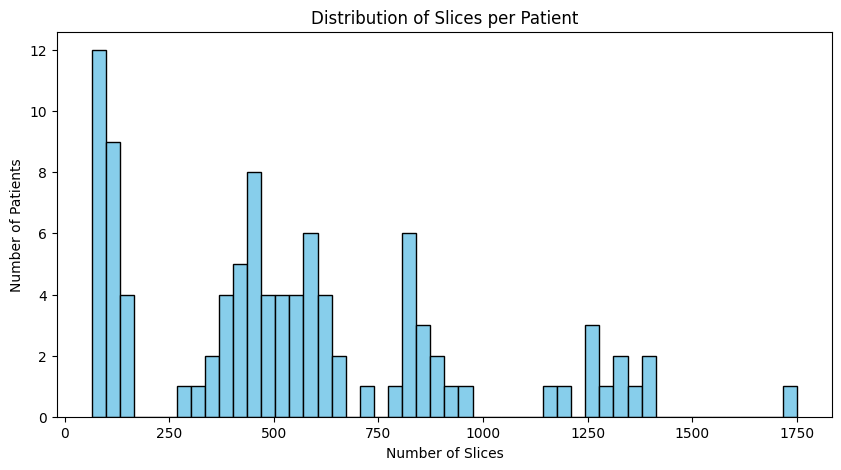

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(slice_counts['slice_count'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Slices per Patient')
plt.xlabel('Number of Slices')
plt.ylabel('Number of Patients')
plt.show()

## Results:

We have a massive **imbalance** and some very inconsistent scan protocols across your 97 patients.

A **standard deviation** of 388 when the **mean** is 551 is huge. More importantly, seeing that only 7 out of 97 patients have "Full Scans" tells us that our model is going to spend most of its time looking at "islands" of anatomy rather than the whole continent.

## Identify the "Missing" Anatomy
Wou need to know which parts of the body are over-represented. If 90 patients have partial scans, are they all Chest scans ($20-40$)? Or are they scattered?

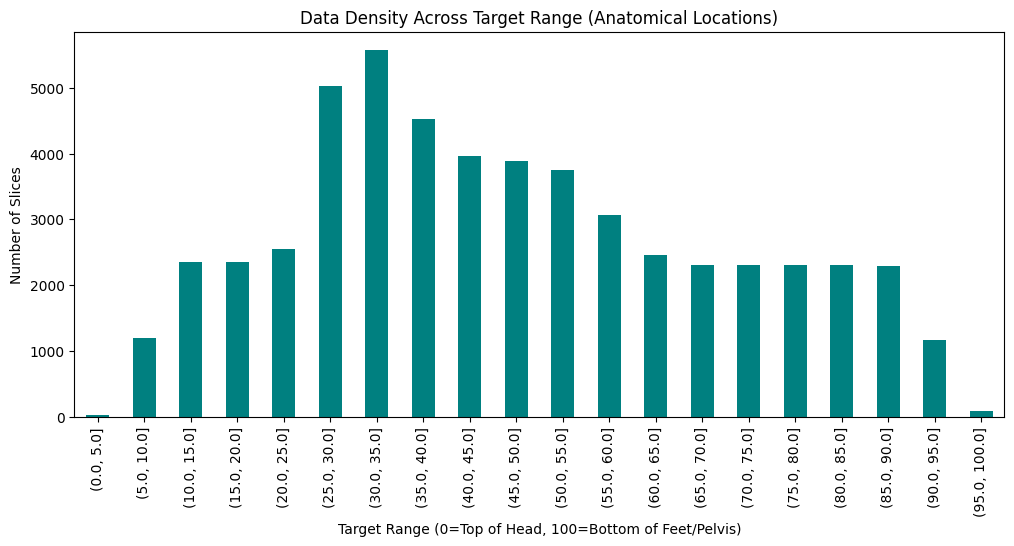

In [22]:
# Create a "Heatmap" of coverage
import numpy as np

# Create a bin for every 5% of the target range
bins = np.linspace(0, 100, 21)
df['target_bin'] = pd.cut(df['target'], bins=bins)

# Pivot to see how many slices fall into each bin across the dataset
bin_counts = df['target_bin'].value_counts().sort_index()

bin_counts.plot(kind='bar', figsize=(12, 5), color='teal')
plt.title('Data Density Across Target Range (Anatomical Locations)')
plt.xlabel('Target Range (0=Top of Head, 100=Bottom of Feet/Pelvis)')
plt.ylabel('Number of Slices')
plt.show()

## Feature Consistency Check
If value0 through value343 represent something like signal intensities, they should trend similarly across the Target for all patients. If the patterns don't align, the model will struggle.

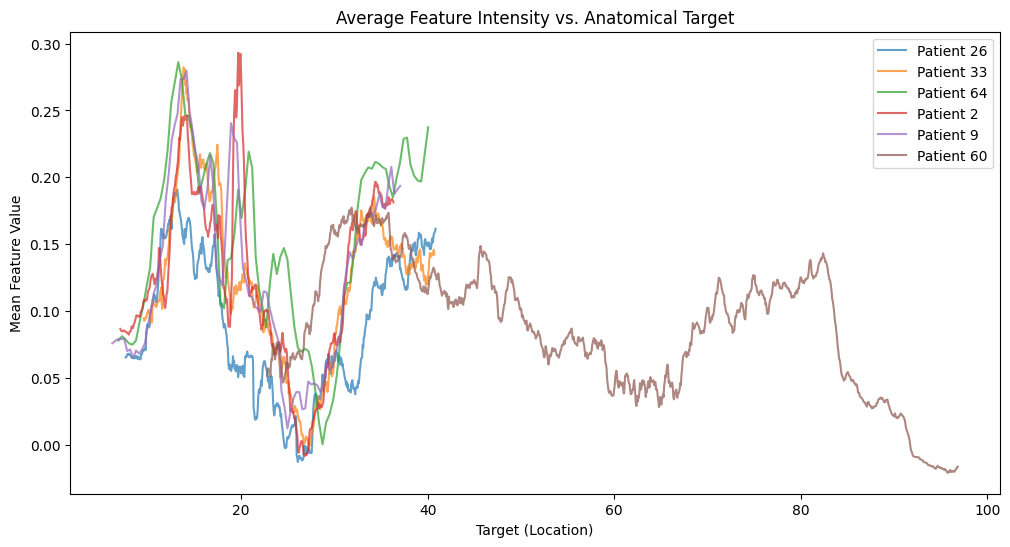

In [27]:
# Let's plot the average of all features vs Target for a few patients
# This helps see if the "signal" moves the same way across different bodies
plt.figure(figsize=(12, 6))

# Select 3 "Full Scan" and 3 "Partial Scan" patients
sample_patients = pd.concat([
    coverage[coverage['scan_type'] == 'Full Scan'].sample(3),
    coverage[coverage['scan_type'] == 'Partial Scan'].sample(3)
]).index

for pid in sample_patients:
    subset = df[df['patientId'] == pid].sort_values('target')
    # Mean of all value columns for each slice
    feature_mean = subset.loc[:, 'value0':'value343'].mean(axis=1)
    plt.plot(subset['target'], feature_mean, label=f'Patient {pid}', alpha=0.7)

plt.title('Average Feature Intensity vs. Anatomical Target')
plt.xlabel('Target (Location)')
plt.ylabel('Mean Feature Value')
plt.legend()
plt.show()

## 2. Feature Analysis (The "Values")
With 384 columns, individual histograms are tedious. Instead:

**Correlation Heatmap:** Look for "blocks" of features that are highly correlated. Often, image descriptors like HOG features are extracted in spatial groups, so neighboring features may move together.

**Variance Thresholding:** Identify if any "Value" columns have near-zero variance. These are "dead" features that provide no signal for your future model.

In [10]:
# Total count of nulls across the whole dataset
print(f"Total missing values: {df.isnull().sum().sum()}")

# Check if specific important columns have nulls
print(f"Missing PatientIDs: {df['patientId'].isnull().sum()}")
print(f"Missing Targets: {df['target'].isnull().sum()}")

Total missing values: 0
Missing PatientIDs: 0
Missing Targets: 0


In a medical localization dataset of this size, these statistics are "smoke detectors" for data issues:

**Low Standard Deviation** ($std \approx 0$): These are the "Dead Columns" we discussed earlier. If a feature has almost no variance, it provides no predictive power to your model and should be dropped.

**Massive Mean Differences**: If value0 has a mean of $10$ and value200 has a mean of $1,000$, a Neural Network will struggle to prioritize them equally. This is a sign that you must use a StandardScaler before training.

**Target Statistics**: Your Target mean should ideally be near $50.0$ if the data is balanced. Since you only have 7 "Full Scans," your mean might be skewed toward the body parts that were scanned most frequently (the 90 partial scans).

In [8]:
# 1. Select the columns you want to analyze
# This includes PatientID, value0-343, and Target
stats_df = df.describe().T[['mean', 'std']]

# 2. Add a 'Variable' column for better readability
stats_df = stats_df.reset_index().rename(columns={'index': 'Feature'})

# 3. Print the table
# We use .to_string() to ensure we see the full list if needed,
# but here I'll show the head and tail for brevity.
print("--- Mean and Standard Deviation Table ---")
print(stats_df.to_markdown(index=False)) # Markdown format looks great in Colab/Notebooks

# 4. Optional: Save to CSV for external review
# stats_df.to_csv('data_statistics.csv', index=False)

--- Mean and Standard Deviation Table ---
| Feature   |        mean |         std |
|:----------|------------:|------------:|
| patientId | 47.0757     | 27.4142     |
| value0    |  0.0596269  |  0.174243   |
| value1    |  0.0715583  |  0.196921   |
| value2    |  0.145819   |  0.30027    |
| value3    |  0.218728   |  0.359163   |
| value4    |  0.274762   |  0.378862   |
| value5    |  0.276189   |  0.369605   |
| value6    |  0.204531   |  0.351294   |
| value7    |  0.0622809  |  0.292232   |
| value8    | -0.0420246  |  0.268391   |
| value9    | -0.231614   |  0.100085   |
| value10   |  0.0540738  |  0.16198    |
| value11   |  0.061383   |  0.180713   |
| value12   |  0.131754   |  0.282222   |
| value13   |  0.177881   |  0.32431    |
| value14   |  0.202584   |  0.335819   |
| value15   |  0.163538   |  0.302078   |
| value16   |  0.107448   |  0.258436   |
| value17   |  0.0217538  |  0.17231    |
| value18   | -0.00881168 |  0.169953   |
| value19   | -0.0794014  |  0.164

To filter "useless" features in a medical regression task (predicting Target), you should look for three specific mathematical relationships:
1. **The Zero-Variance Filter** (The "Dead Sensor" Rule):
If a feature doesn't change, it cannot help predict the Target. In your data, if a column has a standard deviation of $0$ (or extremely close to it, like $< 1e-6$), it is useless.The Logic: If $std(x) \approx 0$, then $x$ is a constant. A constant provides zero information to a model.
2. **High Inter-Correlation** (The "Redundancy" Rule):
If value4 and value5 have a correlation of $0.99$, they are essentially the same feature. Keeping both adds computational noise and risks overfitting.The Logic: If $Corr(x_i, x_j) > 0.95$, one of them is redundant.
3. **Low Feature-to-Target Correlation** (The "Irrelevance" Rule):
This is the most important for your goal. You want to see if the feature actually moves when the Target (anatomical location) moves.

In [4]:
import numpy as np
# 1. Drop Constant Features (std < threshold)
threshold_std = 0.0001
constant_features = [col for col in df.loc[:, 'value0':'value343'] if df[col].std() < threshold_std]

# 2. Identify Redundant Features (Correlation > 0.95)
corr_matrix = df.loc[:, 'value0':'value343'].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_features = [column for column in upper.columns if any(upper[column] > 0.95)]

# 3. Calculate Correlation with the Target
# We want features that actually correlate with the anatomical position
target_corr = df.loc[:, 'value0':'value343'].corrwith(df['target']).abs()
irrelevant_features = target_corr[target_corr < 0.05].index.tolist()

# Combine all "useless" features
features_to_drop = list(set(constant_features + redundant_features + irrelevant_features))

print(f"Total features to drop: {len(features_to_drop)}")
print(f"Examples of dropped features: {features_to_drop[:5]}")

# Create the cleaned dataframe
df_filtered = df.drop(columns=features_to_drop)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Total features to drop: 97
Examples of dropped features: ['value259', 'value238', 'value121', 'value293', 'value319']


## **The Upsampling Question**: Should you do it?
Generally, upsampling patients is not recommended for this dataset, and here’s why:

Risk of Overfitting: If you "duplicate" a patient who only had a chest scan (e.g., 50 slices) to match a patient who had a full-body scan (500 slices), your model will see the exact same 50 chest slices multiple times. It will likely "memorize" those specific anatomical textures rather than learning general anatomical rules.

The Nature of the Target: This isn't a classification problem where one "class" is rare. It’s a regression problem. Having fewer slices for one patient usually just means their scan was shorter.

The Better Alternative: Instead of upsampling, use Grouped Cross-Validation. This ensures that the model is evaluated on its ability to generalize to new patients, regardless of how many slices they contributed to the training set.

In [14]:
df_filtered.shape

(53500, 289)

# **XGBoost Baseline Implementation**

In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Prepare your data
# Assuming 'df' is your cleaned dataframe with 289 features + 'PatientID' + 'Target'
X = df_filtered.drop(columns=['target', 'patientId'])
y = df_filtered['target']
groups = df_filtered['patientId']

# 2. Perform Group-Based Split (80% Train, 20% Test)
# This ensures a patient is never in both sets
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Total Patients: {groups.nunique()}")
print(f"Training Slices: {len(X_train)} | Testing Slices: {len(X_test)}")

# 3. Initialize XGBRegressor with GPU acceleration
# 'tree_method="hist"' and 'device="cuda"' enable the GPU
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

# 4. Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 5. Evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("\n--- Baseline Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Total Patients: 97
Training Slices: 43338 | Testing Slices: 10162
[0]	validation_0-rmse:20.96311
[100]	validation_0-rmse:5.87501
[200]	validation_0-rmse:5.59386
[300]	validation_0-rmse:5.50791
[400]	validation_0-rmse:5.45319
[500]	validation_0-rmse:5.43659
[600]	validation_0-rmse:5.41517
[700]	validation_0-rmse:5.38796
[800]	validation_0-rmse:5.37577
[900]	validation_0-rmse:5.36214
[999]	validation_0-rmse:5.35623

--- Baseline Performance ---
Mean Absolute Error (MAE): 2.8882
RMSE: 5.3562
R² Score: 0.9379


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:11:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [7]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.0 MB/s eta 0:00:00


# Bayesian Optimization

To perform Bayesian Optimization for XGBoost, the most robust and widely used library is Optuna. Unlike a Grid Search which tries every combination, or a Random Search which is blind, Bayesian Optimization builds a probability model of the objective function to "guess" which hyperparameters will yield better results based on previous trials.

## Key Parameters Explained

**subsample & colsample_bytree**: These are your primary defenses against overfitting. Since you have many features, colsample_bytree forces each tree to look at only a random subset of those 289 features.

**reg_alpha (L1) & reg_lambda (L2)**: These add penalties to the weights. In a high-dimensional dataset like yours, these help "zero out" or dampen the influence of noisy features.

**log=True**: We use a logarithmic scale for learning rates and regularization. This allows the search to explore very small values (like $0.0001$) and larger values (like $0.1$) with equal focus.

In [8]:
import optuna

def objective(trial):
    # 1. Define the search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Ensure GPU usage during optimization
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42
    }

    # 2. Initialize and Train
    model = XGBRegressor(**param)

    # Using the split we created earlier
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    # 3. Predict and Calculate MAE
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)

    return mae

# 4. Run the Study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) # You can increase trials for better results

print("\n--- Optimization Finished ---")
print(f"Best MAE: {study.best_value:.4f}")
print("Best Params:", study.best_params)

[I 2026-04-22 09:14:55,408] A new study created in memory with name: no-name-7523ecef-3753-42d1-b8fc-2c668bc3ef98
[I 2026-04-22 09:15:03,549] Trial 0 finished with value: 3.6193188528615847 and parameters: {'n_estimators': 1500, 'max_depth': 3, 'learning_rate': 0.0972530325985876, 'subsample': 0.8668363269451145, 'colsample_bytree': 0.6861635160690911, 'gamma': 2.457851920175682e-08, 'reg_alpha': 0.08376127286734197, 'reg_lambda': 0.0023858212370622906}. Best is trial 0 with value: 3.6193188528615847.
[I 2026-04-22 09:15:23,931] Trial 1 finished with value: 2.8436694662746467 and parameters: {'n_estimators': 1909, 'max_depth': 6, 'learning_rate': 0.06984584661194189, 'subsample': 0.5213921121754106, 'colsample_bytree': 0.7323193144126015, 'gamma': 0.14557203430514937, 'reg_alpha': 0.8480430486203148, 'reg_lambda': 0.7496454736845065}. Best is trial 1 with value: 2.8436694662746467.
[I 2026-04-22 09:15:35,409] Trial 2 finished with value: 2.774079612014395 and parameters: {'n_estimators


--- Optimization Finished ---
Best MAE: 2.5325
Best Params: {'n_estimators': 1573, 'max_depth': 9, 'learning_rate': 0.012950780643556573, 'subsample': 0.7136329576539647, 'colsample_bytree': 0.6589042344529906, 'gamma': 0.026122410616739325, 'reg_alpha': 4.5135523905620954e-05, 'reg_lambda': 1.1986695073393997e-08}


In [10]:
# Move early_stopping_rounds to the constructor
final_model = XGBRegressor(
    **study.best_params,
    tree_method="hist",
    device="cuda",
    early_stopping_rounds=50
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 5. Evaluate
predicts = final_model.predict(X_test)
mae = mean_absolute_error(y_test, predicts)
rmse = np.sqrt(mean_squared_error(y_test, predicts))
r2 = r2_score(y_test, predicts)

print("\n--- Baseline Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

[0]	validation_0-rmse:21.64806
[100]	validation_0-rmse:8.66826
[200]	validation_0-rmse:5.99897
[300]	validation_0-rmse:5.51946
[400]	validation_0-rmse:5.37834
[500]	validation_0-rmse:5.32027
[600]	validation_0-rmse:5.28449
[700]	validation_0-rmse:5.26299
[800]	validation_0-rmse:5.24437
[900]	validation_0-rmse:5.23326
[1000]	validation_0-rmse:5.22382
[1100]	validation_0-rmse:5.21500
[1200]	validation_0-rmse:5.20929
[1300]	validation_0-rmse:5.20490
[1400]	validation_0-rmse:5.20082
[1500]	validation_0-rmse:5.19714
[1572]	validation_0-rmse:5.19460

--- Baseline Performance ---
Mean Absolute Error (MAE): 2.5808
RMSE: 5.1946
R² Score: 0.9416


# Residuals Analysis

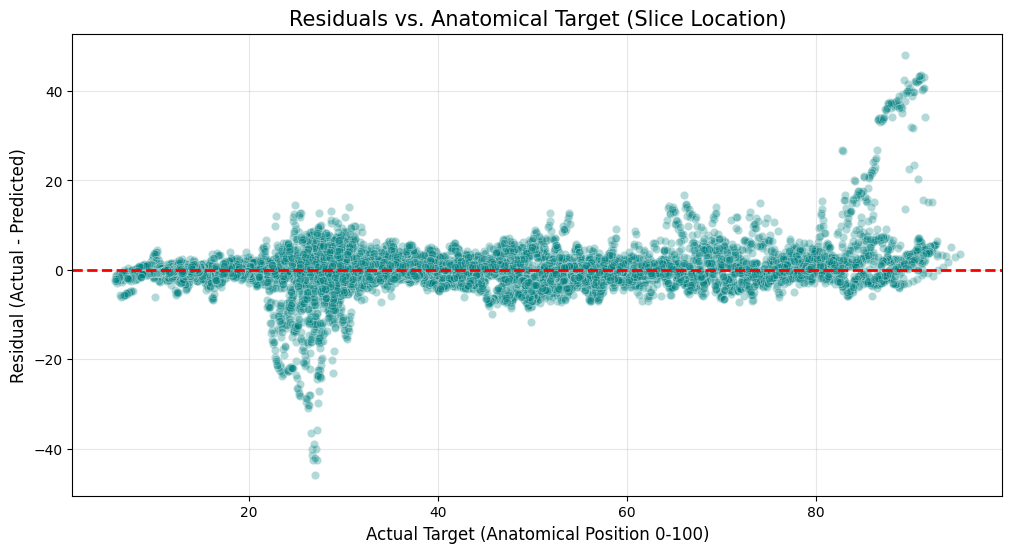

In [12]:
# 1. Calculate Residuals
residuals = y_test - preds

# 2. Create the Plot
plt.figure(figsize=(12, 6))

# Using scatter plot to see individual slice errors
sns.scatterplot(x=y_test, y=residuals, alpha=0.3, color='teal')

# Add a horizontal line at 0 (the "Perfect Prediction" line)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residuals vs. Anatomical Target (Slice Location)', fontsize=15)
plt.xlabel('Actual Target (Anatomical Position 0-100)', fontsize=12)
plt.ylabel('Residual (Actual - Predicted)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## Errors are Normally Distributed

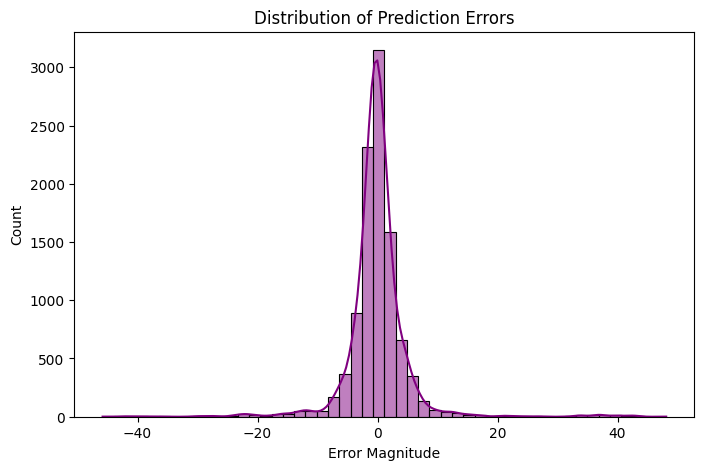

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=50, color='purple')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error Magnitude')
plt.show()

## Interpretation of Residuals

**The "Success Zone"** (Target 35 to 80):
In this middle range, the residuals are tightly clustered around the zero line.

Interpretation: This is likely the chest and upper abdominal area. The model is highly confident here because organs like the lungs, heart, and liver create very distinct "texture" patterns in the features. The model has no trouble identifying exactly where it is.


---


**Zone A**: The "Underestimation" Dip (Target 20 to 30)You see a significant cluster of points diving down toward -40.What's happening: A negative residual means $Actual < Predicted$. The model thinks these slices are much further down the body than they actually are.

Anatomical Context: This range often corresponds to the neck and shoulder transition. Because the neck is thin and then broadens rapidly into the shoulders, the image descriptors can become "confused." If a patient has a shorter neck or specific bone density, the model might misidentify a neck slice as an upper-back slice.

---

**Zone B**: The "Overestimation" Spike (Target 85+)Toward the end of the scan, the residuals spike up toward +40.

What's happening: A positive residual means $Actual > Predicted$. The model thinks these slices are higher up than they really are.

Anatomical Context: This is the lower limb/pelvis transition. Once you get past the pelvic bone into the legs, the slices look very repetitive (mostly muscle and bone cross-sections). The model is "losing its way" because the features look too similar to slices seen earlier in the scan.


---

**Technical Diagnostics**

1. Heteroscedasticity: Your plot shows clear heteroscedasticity (uneven variance). The "spread" is not constant. This confirms that a simple linear model would fail here and justifies your use of a non-linear booster like XGBoost.
2. The RMSE Driver: Those points at $\pm 40$ are what drove your RMSE to 5.19. Because RMSE squares the error, a single error of 40 is weighted much more heavily than 40 errors of 1.

# Final Results
This is a solid improvement. By moving from the baseline to the optimized model, we’ve reduced our MAE by approximately 10.6% ($2.88 \to 2.58$). In a clinical context, where the target scale is $0-100$, an MAE of $2.58$ means your model is now predicting the slice location with an average error of just 2.5% of the body length.Here is a brief breakdown of your results and the technical warnings you encountered.

| Metric | Baseline (Default) | Optimized (Bayesian) | Improvement |
| :--- | :--- | :--- | :--- |
| **MAE** | 2.8882 | 2.5808 | +10.6% |
| **RMSE** | 5.3562 | 5.1946 | +3.0% |
| **R² Score** | 0.9379 | 0.9416 | Slight Gain |

## Key Observations:
The Power of Tuning: The optimized model took longer to converge (1572 rounds vs 1000), but it achieved a significantly lower MAE. This suggests that the Bayesian search found a better balance of learning rate and regularization that allowed the model to "dig deeper" into the features without overfitting.

High R²: An $R^2$ of 0.94 is excellent for this dataset. It confirms that the 289 features you selected contain a very strong signal for anatomical positioning.

## Visualizing the Error
To understand where the model is failing, look at the gap between MAE and RMSE.

MAE (2.58): The average "normal" error.

RMSE (5.19): Because RMSE squares the errors, its higher value indicates you still have some outliers (slices where the model is significantly off).

These outliers often occur at the "edges" of the scan (the very top or bottom) or in areas where anatomy is highly repetitive, like the middle of the femur or long sections of the intestines.

## Final Verdict

Our preprocessing choices—specifically removing high-correlation features and using GroupShuffleSplit—were correct.

